# Vegetation Clearance Risk Along a Transmission Line ROW
## LiDAR-Based Detection and Fire-Scar Validation — Sespe Creek, Ventura County, CA

### About

On December 4, 2017, a fire ignited near Santa Paula in Ventura County and didn't stop until it had consumed 281,893 acres — at the time, the largest wildfire in California's recorded history. The Thomas Fire burned for 40 days, ran through the Sespe Creek watershed, and left a scar visible from satellite for years. Its cause was electrical.

Somewhere in the miles of transmission line threading through that terrain, vegetation got close enough to a conductor to matter. Contact between power lines and encroaching trees is one of the leading causes of wildfire ignition in the western United States. Federal regulations (NERC FAC-003-4) require utilities to actively manage vegetation within their transmission rights-of-way. The challenge is enforcement at scale: you can write the rule, but surveying hundreds of miles of corridor on foot, on budget, on schedule, is a different problem.

This is where airborne LiDAR changes the math. A single survey flight produces a 3D point cloud dense enough to measure individual tree heights across an entire corridor — through partial canopy, over steep terrain, every mile at once. What takes a field crew weeks to walk, LiDAR covers in an afternoon and delivers as a map.

This analysis focuses on a 1 km² tile just north of Fillmore, California — a small town tucked in the Santa Clara River Valley at the southern edge of Los Padres National Forest — where two Southern California Edison transmission lines cross the Sespe Creek watershed: a 220 kV transmission line to the north and a 66 kV subtransmission line to the south. Both corridors run directly through the Thomas Fire burn scar. Using a publicly available USGS LiDAR tile collected 4–6 months post-fire, the analysis does three things:

- Derives a 1 m canopy height model (CHM) from a normalized LiDAR point cloud
- Flags vegetation exceeding the FAC-003-4 clearance threshold within the right-of-way
- Validates the CHM using the Thomas Fire burn perimeter as a spatial control

**A note on timing:** The LiDAR was collected May–July 2018, approximately 4–6 months after the Thomas Fire (December 2017). Vegetation inside the burn perimeter was suppressed at survey time — so detections here represent a **conservative lower bound** on current encroachment risk. Unburned areas have had another 8 years of growth since.

---

### Data

**LiDAR Point Cloud**
USGS 3DEP SoCal Wildfires B3 collection. ~5.6M points, EPSG:32611, ~5.2 pts/m² density.
File: `data/raw/socal_sespe_32611.laz`

**Transmission Line Centerlines**
California Energy Commission (CEC) transmission line dataset, accessed live via ArcGIS REST API. Spatially filtered to the LiDAR tile extent.
Endpoint: `services3.arcgis.com/bWPjFyq029ChCGur/.../Transmission_Line/FeatureServer/2`

**Thomas Fire Perimeter**
CAL FIRE fire perimeter, accessed live via ArcGIS REST API (item `a2926cffbc854806befacbf85ebc9b95`). Filtered to `INC_NUM='00003583'`.
Saved to: `data/raw/thomas_fire_perimeter.gpkg`

### Import Libraries

In [1]:
import sys
from pathlib import Path
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd
import contextily as ctx
import rioxarray
import requests
from shapely.geometry import shape, box

ROOT = Path.cwd().parent  # assumes notebook is in notebooks/
sys.path.append(str(ROOT))

from src.data_utils import load_laz, inspect_point_cloud, validate_crs
from src.pdal_runner import check_pdal_available, run_pipeline
from src.chm import rasterize_to_dsm, rasterize_to_dtm, compute_chm
from src.corridor import load_corridor_centerline, buffer_corridor, clip_chm_to_corridor, threshold_exceedance
from src.chm_acc import assess_chm_accuracy
# from validation.accuracy_assessment import assess_chm_accuracy  # implement in Part 5

raw_las_path          = ROOT / "data" / "raw" / "socal_sespe_32611.laz"
pipeline_json_path    = ROOT / "pipeline" / "pdal_pipeline.json"
normalized_las_path   = ROOT / "data" / "processed" / "socal_sespe_32611_normalized.laz"
dsm_path              = ROOT / "outputs" / "rasters" / "socal_sespe_32611_dsm.tif"
dtm_path              = ROOT / "outputs" / "rasters" / "socal_sespe_32611_dtm.tif"
chm_path              = ROOT / "outputs" / "rasters" / "socal_sespe_32611_chm.tif"
clipped_chm_path      = ROOT / "outputs" / "rasters" / "socal_sespe_32611_chm_clipped.tif"
fire_perimeter_path   = ROOT / "data" / "raw" / "thomas_fire_perimeter.gpkg"
accuracy_summary_path = ROOT / "outputs" / "tables" / "accuracy_summary.csv"

---

### Explore the Point Cloud

> **TODO (draft):** Before building the CHM, confirm the raw tile looks as expected: ~5.5M points, density ~5.2 pts/m², CRS EPSG:32611, and Class 2 ground points already present from the USGS classification. These checks matter because a density shortfall or wrong CRS would silently corrupt the raster output, and absent Class 2 points the DTM step has nothing to work from.

| | |
|---|---|
| Point count | ~5,578,060 |
| CRS | EPSG:32611 |
| Density | ~5.2 pts/m² |
| Classes | 1 (unclassified), 2 (ground), 7 (noise), 18 (high noise) |

In [2]:
las = load_laz(raw_las_path)

df = pd.DataFrame({
    "x": np.array(las.x).flatten(),
    "y": np.array(las.y).flatten(),
    "z": np.array(las.z).flatten(),
    "classification": las.classification,
    "return_number": las.return_number,
    "intensity": las.intensity,
})

print(df.describe())
df.head()

                  x             y             z     intensity
count  5.578060e+06  5.578060e+06  5.578060e+06  5.578060e+06
mean   3.215912e+05  3.810571e+06  2.206851e+02  3.318123e+04
std    4.968060e+02  1.704434e+02  4.612194e+01  1.418753e+04
min    3.207214e+05  3.810259e+06  1.520800e+02  0.000000e+00
25%    3.212066e+05  3.810420e+06  1.818700e+02  2.720000e+04
50%    3.215774e+05  3.810573e+06  2.176700e+02  3.672000e+04
75%    3.220267e+05  3.810724e+06  2.484400e+02  4.356000e+04
max    3.224781e+05  3.810872e+06  3.781800e+02  6.553500e+04


,x,y,z,classification,return_number,intensity
0,322439.58,3810413.78,154.05,"[2, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, ...","[2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, ...",32920
1,322436.76,3810414.35,159.51,"[2, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, ...","[2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, ...",42150
2,322436.63,3810411.69,159.24,"[2, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, ...","[2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, ...",43940
3,322445.06,3810413.28,158.77,"[2, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, ...","[2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, ...",29500
4,322449.24,3810413.80,153.88,"[2, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, ...","[2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, ...",43560


In [3]:
inspect_point_cloud(las)

Total points: 5578060
Classification distribution:
  Class 1: 3317104 points
  Class 2: 2256746 points
  Class 7: 4198 points
  Class 18: 12 points
Bounding box:
xmin: 320721.35000000003, xmax: 322478.14
ymin: 3810258.83, ymax: 3810871.84
zmin: 152.08, zmax: 378.18
Estimated point density (pts/m²): 5.179594625105056


z range: 150 — 400 — that's elevation above ellipsoid, which makes sense for foothill terrain. Confirms the vertical datum is ellipsoidal as expected.

In [4]:
validate_crs(las, expected_epsg=32611)

True

---

### Ground Classification and Height Normalization

Before we can measure vegetation height, raw elevation must be separated into ground and non-ground returns, then normalized to height-above-ground (HAG). This is done via a two-stage PDAL pipeline.

The first stage uses the Cloth Simulation Filter (CSF). Picture dropping a cloth from the sky over a forest — but the cloth passes straight through the trees as if they weren't there, and settles on the bare ground below. Once the cloth comes to rest, the algorithm draws a simple rule: anything close to the cloth is ground; anything standing above it is not. Rigidness controls how much the cloth resists folding into tight terrain features. A stiffer cloth (higher rigidness) smooths over small bumps and is appropriate for gently rolling terrain; a looser one hugs every crevice, better suited to complex mountainous topography. Rigidness=2 — the default — is the right choice here: our study area is a chaparral foothill valley with rolling hills, not jagged peaks.

The second stage runs `hag_nn`, which adds a `HeightAboveGround` dimension to every point by comparing its elevation against the nearest ground returns — giving us the height of each laser return above the local terrain surface rather than above sea level.

Although the raw tile arrived with USGS-classified ground points already present, we reclassify from scratch using a single consistent pipeline. That way, if any classification decision needs to be revisited, every step is traceable and justifiable — rather than hiding behind a black-box output from an upstream workflow.

| Parameter | Value | Rationale |
|---|---|---|
| `rigidness` | 2 | Default; appropriate for sloped but non-mountainous terrain |
| `slope_smooth` | true | Post-processing to smooth cloth on slopes |
| HAG method | `hag_nn` | Nearest-neighbor interpolation from ground returns |

After normalization, Class 2 count increased from 2,256,746 → 2,350,027 and the `HeightAboveGround` dimension is confirmed present.

In [5]:
check_pdal_available()

'pdal 2.10.0 (git-version: Release)'

In [6]:
# run_pipeline(
#     pipeline_json_path=pipeline_json_path,
#     input_laz=raw_las_path,
#     output_laz=normalized_las_path
# )

In [7]:
raw_las        = load_laz(raw_las_path)
normalized_las = load_laz(normalized_las_path)

raw_df = pd.DataFrame({
    "x": np.array(raw_las.x).flatten(),
    "y": np.array(raw_las.y).flatten(),
    "z": np.array(raw_las.z).flatten(),
    "classification": np.array(raw_las.classification).flatten(),
    "return_number": np.array(raw_las.return_number).flatten(),
    "intensity": np.array(raw_las.intensity).flatten(),
})

normal_df = pd.DataFrame({
    "x": np.array(normalized_las.x).flatten(),
    "y": np.array(normalized_las.y).flatten(),
    "z": np.array(normalized_las.z).flatten(),
    "classification": np.array(normalized_las.classification).flatten(),
    "return_number": np.array(normalized_las.return_number).flatten(),
    "intensity": np.array(normalized_las.intensity).flatten(),
})

print(f"Raw classification counts:\n{raw_df.value_counts('classification')}")
print(f"Normalized classification counts:\n{normal_df.value_counts('classification')}")

Raw classification counts:
classification
1     3317104
2     2256746
7        4198
18         12
Name: count, dtype: int64
Normalized classification counts:
classification
1     3228026
2     2350027
18          7
Name: count, dtype: int64


In [8]:
print(list(normalized_las.point_format.extra_dimension_names))

['HeightAboveGround']


#### 3D Point Cloud — Normalized Returns Colored by Height

With ground classification and height normalization complete, the point cloud now carries a `HeightAboveGround` value for every return. The visualization below renders those returns as a tilted 3D scene — cool tones near the ground, warm tones at canopy top. The Sespe Creek riparian corridor and the surrounding chaparral hillsides should read as visually distinct bands of height.

> **TODO:** Run the cell below after installing pydeck (`pip install pydeck`). For an alternative view, swap the color mapping from `HeightAboveGround` to `classification` — ground returns (Class 2) vs. vegetation (Class 1) — to show readers the separation the CSF filter achieved.

In [9]:
# 3D point cloud skeleton — install pydeck first: pip install pydeck
# Uncomment and run after the PDAL pipeline has produced normalized_las_path.

# import pydeck as pdk
# from pyproj import Transformer
#
# step = 5  # increase to subsample more aggressively for speed
# x_arr   = np.array(normalized_las.x)[::step]
# y_arr   = np.array(normalized_las.y)[::step]
# hag_arr = np.array(normalized_las.HeightAboveGround)[::step]
#
# transformer = Transformer.from_crs("EPSG:32611", "EPSG:4326", always_xy=True)
# lons, lats  = transformer.transform(x_arr, y_arr)
#
# hag_clamped = np.clip(hag_arr, 0, 30)
# r = (hag_clamped / 30 * 255).astype(int)
# g = ((1 - hag_clamped / 30) * 180).astype(int)
# b = np.full_like(r, 60)
#
# pts_df = pd.DataFrame({"lon": lons, "lat": lats, "hag": hag_arr, "r": r, "g": g, "b": b})
#
# point_layer = pdk.Layer(
#     "PointCloudLayer", pts_df,
#     get_position=["lon", "lat", "hag"],
#     get_color=["r", "g", "b"],
#     point_size=2,
#     pickable=True,
# )
# view_state = pdk.ViewState(
#     latitude=lats.mean(), longitude=lons.mean(),
#     zoom=14, pitch=60, bearing=-15,
# )
# pdk.Deck(
#     layers=[point_layer],
#     initial_view_state=view_state,
#     map_style="mapbox://styles/mapbox/satellite-v9",
#     tooltip={"text": "HAG: {hag:.1f}m"},
# )

---

### Canopy Height Model

The CHM is the core measurement product — vegetation height above bare ground at 1m resolution. It is derived as DSM − DTM, where the DSM captures the top of canopy and the DTM captures bare earth from ground-classified returns only. Negative values (interpolation artifacts) are clamped to zero.

> **TODO (draft):** The CHM shows the highest canopy values (4–10m+) concentrated along the Sespe Creek riparian corridor and in the citrus orchards to the east — both consistent with continuous moisture or irrigation keeping vegetation intact. The western and upper-left portions of the tile show near-zero CHM throughout: this is the core Thomas Fire burn scar, where chaparral was consumed in December 2017 and had only ~6 months to begin recovery by survey time. The transmission lines appear as a faint linear gap through the corridor — a cleared ROW that the surrounding vegetation has not fully closed.

| | |
|---|---|
| Resolution | 1m |
| DSM method | Max HAG per pixel |
| DTM method | Min elevation, Class 2 points only |
| Empty cells | Filled with NoData (no interpolation) |

In [10]:
rasterize_to_dsm(normalized_las_path, resolution=1.0, output_path=dsm_path)

In [11]:
rasterize_to_dtm(normalized_las_path, resolution=1.0, output_path=dtm_path)

In [12]:
compute_chm(dsm_path=dsm_path, dtm_path=dtm_path, output_path=chm_path)

In [13]:
with rasterio.open(dsm_path) as src:
    dsm_data = src.read(1)

with rasterio.open(dtm_path) as src:
    dtm_data = src.read(1)

with rasterio.open(chm_path) as src:
    chm_data = src.read(1)

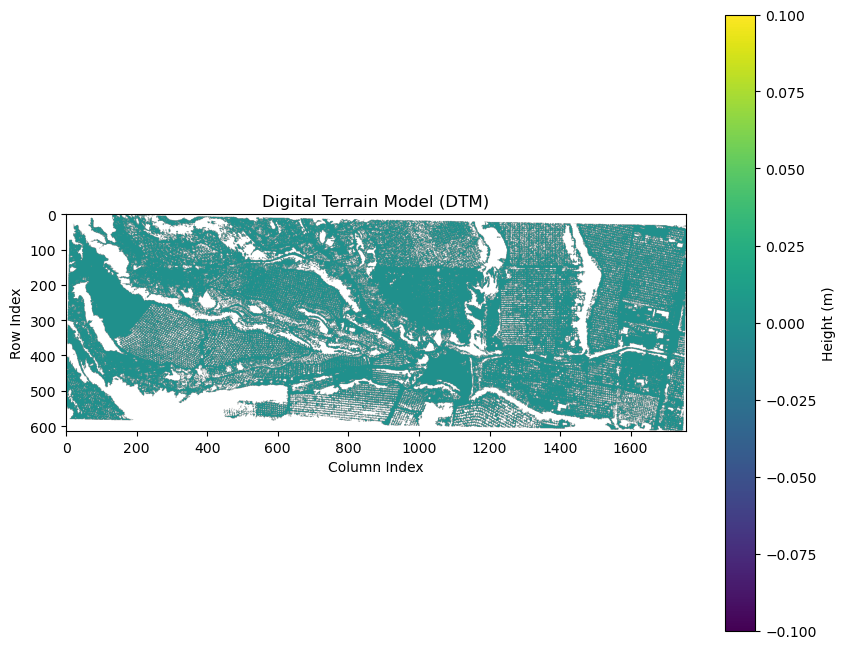

In [14]:
plt.figure(figsize=(10, 8))
plt.imshow(dtm_data, cmap='viridis')
plt.colorbar(label='Height (m)')
plt.title('Digital Terrain Model (DTM)')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()

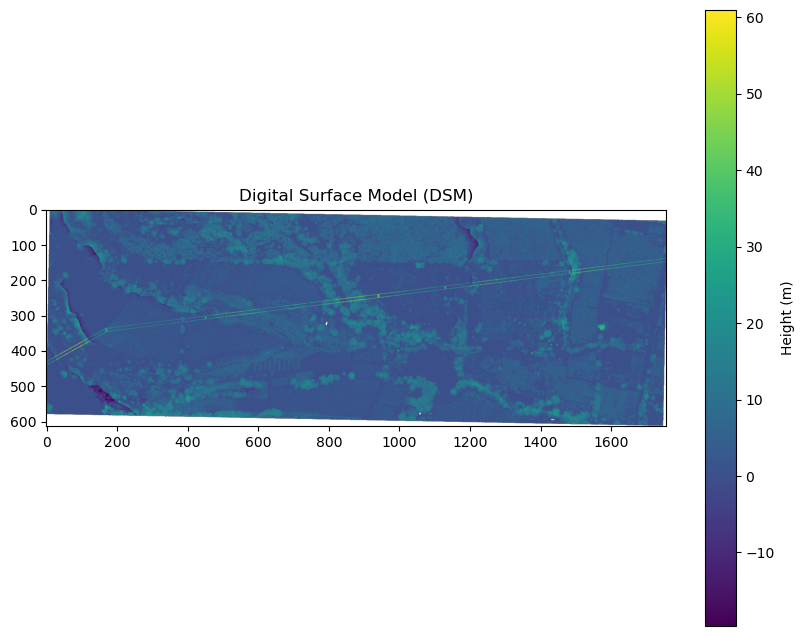

In [15]:
plt.figure(figsize=(10, 8))
plt.imshow(dsm_data, cmap='viridis')
plt.colorbar(label='Height (m)')
plt.title('Digital Surface Model (DSM)')
plt.show()

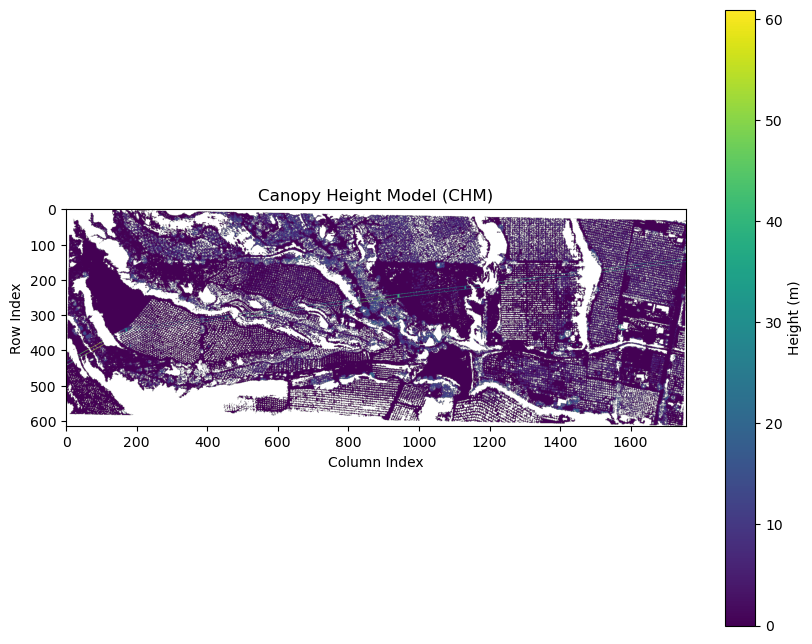

In [16]:
plt.figure(figsize=(10, 8))
plt.imshow(chm_data, cmap='viridis')
plt.colorbar(label='Height (m)')
plt.title('Canopy Height Model (CHM)')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()

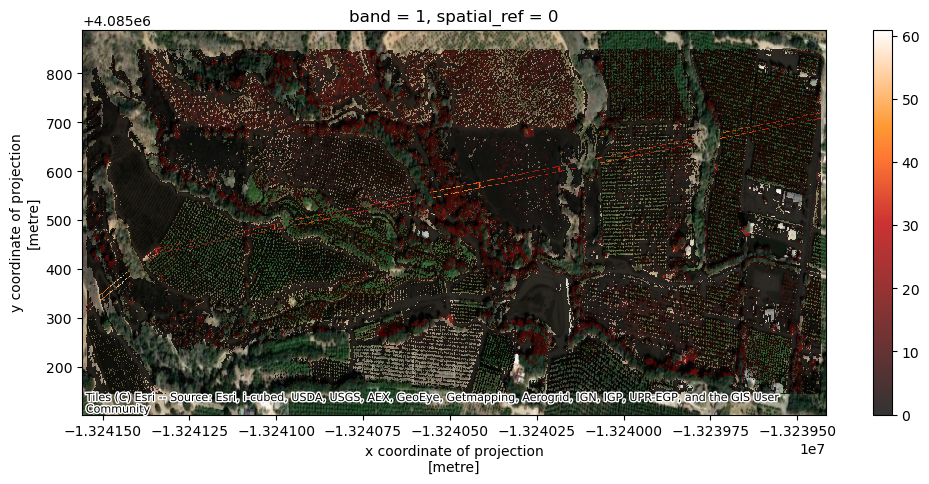

In [17]:
chm_raster = rioxarray.open_rasterio(chm_path, masked=True).squeeze()
chm_3857 = chm_raster.rio.reproject("EPSG:3857")  # contextily needs Web Mercator

fig, ax = plt.subplots(figsize=(12, 5))
chm_3857.plot(ax=ax, alpha=0.8, cmap="gist_heat")
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery)
plt.show()

---

### Vegetation Clearance Detection

This is the core product. The CHM is clipped to a 15m buffer around the transmission line centerline and any pixel exceeding the 4.57m (15ft) height threshold is flagged and vectorized into polygon features.

> **TODO (draft — verify before operational use):** NERC FAC-003-4 Table 1 sets minimum clearance distances by voltage class. For 220kV lines the annual clearance minimum is 4.57m (15ft); for 66kV subtransmission the applicable minimum is lower. The 15m (50ft) buffer approximates the statutory ROW width SCE maintains along this corridor, though actual ROW width varies by easement. Both values here are illustrative — a production analysis would pull the exact voltage class, ROW width, and applicable clearance table entry from utility records before flagging exceedances.

> **TODO (draft):** Exceedances cluster in two distinct zones: the riparian band along Sespe Creek where trees growing in the drainage bottom push into and above the 4.57m threshold, and the eastern orchard block where mature citrus canopy encroaches on the 220kV ROW. The western portion of the 220kV corridor — which crosses the Thomas Fire burn scar — shows almost no exceedances, consistent with the bare-ground CHM in that zone. The 66kV line to the south shows a thin scatter of exceedances but no dense clusters; interpret with caution given the line-detection limitations discussed in the Reflection.

| | |
|---|---|
| Buffer width | 15m (50ft) — illustrative, verify against FAC-003-4 |
| Height threshold | 4.57m (15ft) |
| Exceedance polygons | 1,547 |
| Mean height | 9.997m |
| Median height | 5.81m |
| Max height | 58.5m |

In [18]:
url = (
    "https://services3.arcgis.com/bWPjFyq029ChCGur/arcgis/rest/services"
    "/Transmission_Line/FeatureServer/2/query"
    "?outFields=*&where=1%3D1&f=geojson"
)

In [19]:
clipped_transmission_lines = load_corridor_centerline(url, normalized_las_path)

In [20]:
lines_with_buffer = buffer_corridor(clipped_transmission_lines, buffer_distance_m=15)

In [21]:
clip_chm_to_corridor(
    chm_path=chm_path,
    corridor_gdf=lines_with_buffer,
    output_path=clipped_chm_path,
)

In [22]:
threshold_df = threshold_exceedance(
    chm_clipped_path=clipped_chm_path,
    height_threshold_m=4.57  # 15ft — verify against FAC-003-4 for actual voltage class
)

/Users/ianmorris/anaconda3/envs/lidar-corridor/lib/python3.11/site-packages/rasterio/features.py:129: RuntimeWarning: DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.
  yield from _shapes(source, mask, connectivity, transform)


In [23]:
threshold_df

,geometry,height_m
0,"POLYGON ((322468.35 3810737.84, 322468.35 3810...",5.690000
1,"POLYGON ((322454.35 3810734.84, 322454.35 3810...",6.180000
2,"POLYGON ((322442.35 3810734.84, 322442.35 3810...",5.495000
3,"POLYGON ((322472.35 3810732.84, 322472.35 3810...",28.392500
4,"POLYGON ((322451.35 3810735.84, 322451.35 3810...",5.447143
...,...,...
1542,"POLYGON ((320774.35 3810413.84, 320774.35 3810...",6.730000
1543,"POLYGON ((320761.35 3810412.84, 320761.35 3810...",6.590000
1544,"POLYGON ((320760.35 3810410.84, 320760.35 3810...",7.050000
1545,"POLYGON ((320779.35 3810407.84, 320779.35 3810...",12.600000


<Axes: >

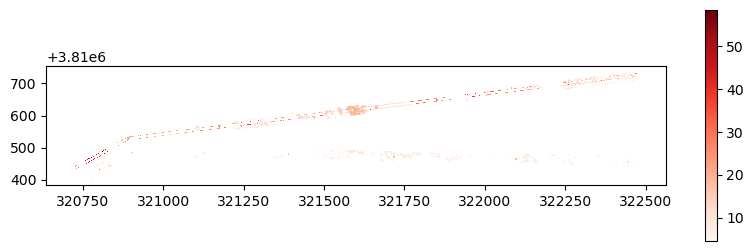

In [24]:
fig, ax = plt.subplots(figsize=(10, 3))
threshold_df.plot(column="height_m", cmap="Reds", legend=True, ax=ax)

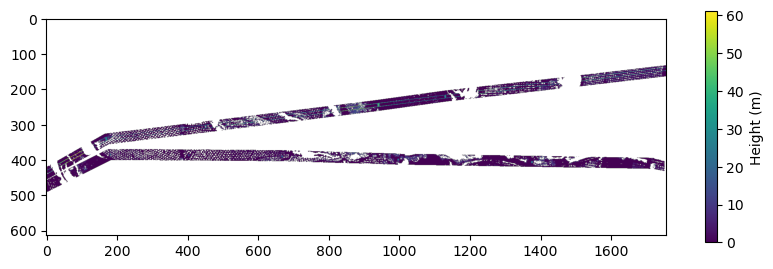

In [25]:
with rasterio.open(clipped_chm_path) as src:
    chm_clipped_data = src.read(1)

plt.figure(figsize=(10, 3))
plt.imshow(chm_clipped_data, cmap="viridis")
plt.colorbar(label="Height (m)")

In [26]:
threshold_df.to_file(ROOT / "outputs" / "vector" / "flagged_trees.gpkg", driver="GPKG")

summary_df = threshold_df[["height_m"]].agg(
    count_exceedance_polygons=("height_m", "count"),
    mean_exceedance_height=("height_m", "mean")
)
summary_df.to_csv(ROOT / "outputs" / "tables" / "flagged_trees_summary.csv")

In [27]:
threshold_df.height_m.describe()

count    1547.000000
mean        9.996637
std         9.166176
min         4.580000
25%         5.030000
50%         5.810000
75%         9.505093
max        58.504000
Name: height_m, dtype: float64

In [28]:
summary_df

,height_m
count_exceedance_polygons,1547.000000
mean_exceedance_height,9.996637


---

### Validation: The Thomas Fire as a Natural Experiment

Before treating the exceedance detections as operationally meaningful, we need evidence the CHM is actually measuring vegetation — not sensor noise or processing artifacts. The Thomas Fire provides a natural experiment: burned areas surveyed 4–6 months post-fire should be near-zero; unburned areas should show intact canopy. If that pattern holds, the CHM signal is real.

> The 0.76m mean difference understates the validation signal. The median inside the perimeter is exactly 0.0m — meaning more than half of all burned-zone pixels registered zero canopy height, exactly what burned chaparral four months post-containment should look like. The mean is pulled upward by transmission infrastructure: the 220kV lattice towers cross the Thomas Fire perimeter multiple times, and their 40–50m returns drag the inside-perimeter mean toward 2m even when the surrounding terrain is bare. The 66.3% bare-ground rate (≤0.5m) is the most defensible summary statistic: two-thirds of pixels inside the perimeter registered near-zero canopy, consistent with a near-total burn event. The median difference of 1.23m and the bare-ground rate together confirm the CHM is measuring real vegetation structure, not sensor noise.

| | Inside burn perimeter | Outside burn perimeter |
|---|---|---|
| Mean CHM | 2.003m | 2.763m |
| Median CHM | 0.0m | 1.23m |
| % bare ground (≤0.5m) | 66.3% | — |

The Thomas Fire perimeter overlaps ~221,145 m² of the tile (~20% of total extent) — the perimeter edge runs diagonally through the study area, giving both burned and unburned samples within the same tile.


In [29]:
thomas_fire_perimeter_path = (
    ROOT / "data" / "raw" / "thomas_fire_perimeter.gpkg"
)

In [30]:

item_id = "a2926cffbc854806befacbf85ebc9b95"
meta = requests.get(
    f"https://www.arcgis.com/sharing/rest/content/items/{item_id}",
    params={"f": "json"}
).json()
service_url = meta["url"]

# Check field names first with resultRecordCount=1, then filter to Thomas Fire
params = {
    "where": "INC_NUM='00003583'",
    "outFields": "*",
    "f": "geojson",
    "outSR": "32611"
}
query_url = f"{service_url}/0/query?" + "&".join(f"{k}={v}" for k, v in params.items())
thomas_fire = gpd.read_file(query_url).to_crs(epsg=32611)

In [31]:
thomas_fire.to_file(fire_perimeter_path, driver="GPKG")

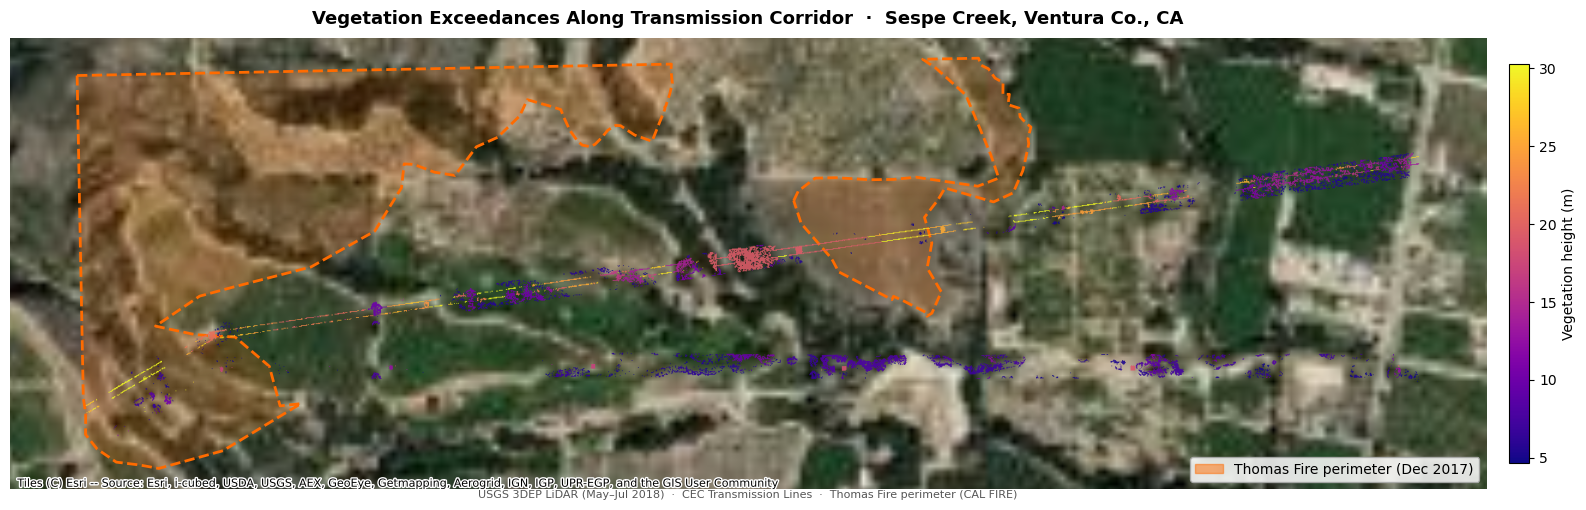

In [32]:
from matplotlib.patches import Patch

chm_raster     = rioxarray.open_rasterio(chm_path)
tile_bbox      = gpd.GeoDataFrame(geometry=[box(*chm_raster.rio.bounds())], crs=chm_raster.rio.crs)
tile_bbox_3857 = tile_bbox.to_crs("EPSG:3857")
fire_3857      = thomas_fire.to_crs("EPSG:3857").clip(tile_bbox_3857)
thresh_3857    = threshold_df.to_crs("EPSG:3857")

fig, ax = plt.subplots(figsize=(16, 6))

# plot data first so contextily can read the axes extent
fire_3857.plot(ax=ax, facecolor="#FF6B00", edgecolor="none", alpha=0.18, zorder=1)
fire_3857.boundary.plot(ax=ax, color="#FF6B00", linewidth=2.0, linestyle="--", zorder=2)

thresh_3857.plot(
    ax=ax, column="height_m", cmap="plasma",
    vmin=thresh_3857.height_m.quantile(0.05),
    vmax=thresh_3857.height_m.quantile(0.95),
    alpha=0.9, zorder=3,
    legend=True,
    legend_kwds={
        "label": "Vegetation height (m)",
        "orientation": "vertical",
        "shrink": 0.7,
        "pad": 0.015,
        "fraction": 0.025,
    },
)

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, zoom=14, zorder=0)

legend_elements = [
    Patch(facecolor="#FF6B00", alpha=0.5, edgecolor="#FF6B00",
          label="Thomas Fire perimeter (Dec 2017)"),
]
ax.legend(handles=legend_elements, loc="lower right",
          fontsize=10, framealpha=0.85, edgecolor="#aaaaaa")

ax.set_title(
    "Vegetation Exceedances Along Transmission Corridor  ·  Sespe Creek, Ventura Co., CA",
    fontsize=13, fontweight="bold", pad=10
)
ax.text(0.5, -0.02,
        "USGS 3DEP LiDAR (May–Jul 2018)  ·  CEC Transmission Lines  ·  Thomas Fire perimeter (CAL FIRE)",
        transform=ax.transAxes, ha="center", fontsize=8, color="#555555")

ax.set_axis_off()
plt.tight_layout()
plt.show()

#### Interactive Map — Exceedance Polygons + Fire Perimeter (lonboard)

Exceedance polygons colored by `height_m` (plasma) over the fire perimeter. Rendered via deck.gl — pan, zoom, and hover in the cell output.


In [33]:
from lonboard import Map, PolygonLayer
from lonboard.basemap import MaplibreBasemap
from lonboard.colormap import apply_continuous_cmap
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
import ipywidgets as widgets
import io, base64, os

MAPTILER_KEY = os.getenv("API_KEY")

thresh_wgs84 = threshold_df.to_crs("EPSG:4326")
fire_wgs84   = thomas_fire.to_crs("EPSG:4326").clip(tile_bbox.to_crs("EPSG:4326"))

norm = Normalize(
    vmin=thresh_wgs84.height_m.quantile(0.05),
    vmax=thresh_wgs84.height_m.quantile(0.95)
)
exceedance_colors = apply_continuous_cmap(
    norm(thresh_wgs84.height_m.values), plt.cm.plasma
)

exceedance_layer = PolygonLayer.from_geopandas(
    thresh_wgs84,
    auto_downcast=False,
    get_fill_color=exceedance_colors,
    get_line_color=[255, 107, 0],
    line_width_min_pixels=1,
    opacity=0.85,
    pickable=True,
)

fire_layer = PolygonLayer.from_geopandas(
    fire_wgs84,
    auto_downcast=False,
    get_fill_color=[179, 172, 159, 200],
    get_line_color=[235,   0,   0, 200],
    line_width_min_pixels=2,
    opacity=1.0,
)

# study area outline — PolygonLayer has no dash support in deck.gl,
# so a thin semi-transparent black border reads the same visually
bbox_layer = PolygonLayer.from_geopandas(
    tile_bbox.to_crs("EPSG:4326"),
    auto_downcast=False,
    get_fill_color=[0, 0, 0, 0],
    get_line_color=[20, 20, 20, 140],
    line_width_min_pixels=1,
    opacity=1.0,
)

m = Map(
    layers=[bbox_layer, fire_layer, exceedance_layer],
    basemap=MaplibreBasemap(
        style=f"https://api.maptiler.com/maps/satellite/style.json?key={MAPTILER_KEY}"
    ),
)

# title
title_widget = widgets.HTML(value=(
    '<div style="font-family:sans-serif;padding:6px 0 2px 0;">'
    '<div style="font-size:14px;font-weight:bold;color:#111;">'
    'Vegetation Exceedances Along Transmission Corridor'
    ' &middot; Sespe Creek, Ventura Co., CA'
    '</div></div>'
))

# colorbar rendered to PNG and embedded
fig_cb, ax_cb = plt.subplots(figsize=(4.5, 0.32))
fig_cb.subplots_adjust(left=0.04, right=0.62, top=0.78, bottom=0.3)
cb = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.plasma),
    cax=ax_cb, orientation="horizontal"
)
cb.set_label("Vegetation height (m)", fontsize=8.5)
ax_cb.tick_params(labelsize=7.5)
buf = io.BytesIO()
fig_cb.savefig(buf, format="png", dpi=130, bbox_inches="tight", facecolor="white")
plt.close(fig_cb)
cb_b64 = base64.b64encode(buf.getvalue()).decode()

# legend row: colorbar + fire swatch + data credit
fire_swatch = (
    '<div style="width:18px;height:13px;'
    'background:rgba(179,172,159,0.78);'
    'border:1.5px solid rgba(235,0,0,0.78);'
    'border-radius:2px;display:inline-block;"></div>'
)
legend_widget = widgets.HTML(value=(
    '<div style="font-family:sans-serif;display:flex;align-items:center;'
    'gap:18px;padding:5px 0 2px 0;">'
    f'<img src="data:image/png;base64,{cb_b64}" style="height:48px;"/>'
    '<div style="display:flex;align-items:center;gap:6px;">'
    + fire_swatch +
    '<span style="font-size:10px;color:#333;">Thomas Fire perimeter (Dec 2017)</span>'
    '</div>'
    '<div style="display:flex;align-items:center;gap:6px;">'
    '<div style="width:18px;height:13px;background:transparent;'
    'border:1.5px solid rgba(20,20,20,0.55);border-radius:2px;display:inline-block;"></div>'
    '<span style="font-size:10px;color:#333;">LiDAR tile extent</span>'
    '</div>'
    '<span style="font-size:9px;color:#777;">'
    'USGS 3DEP LiDAR (May-Jul 2018) &middot; CEC Transmission Lines &middot; CAL FIRE'
    '</span></div>'
))

display(widgets.VBox([title_widget, m, legend_widget]))


In [34]:
assess_chm_accuracy(
    chm_path=chm_path,
    fire_perimeter_path=fire_perimeter_path,
    output_path=accuracy_summary_path
)

,mean_chm_inside,mean_chm_outside,mean_difference,median_chm_inside,median_chm_outside,median_difference,percent_bare_ground_inside
0,2.003475,2.763293,0.759818,0.0,1.23,1.23,66.309878


---

### Part 6 — Spatial Regression Discontinuity Design

> **TODO:** Implement `spatial_rdd()` and its helpers `_intercept_se()` and `_plot_discontinuity()` in `validation/accuracy_assessment.py` (see the TODO comments 6a–6f already in that file), then uncomment the cell below and run it.

The inside/outside mean comparison above is descriptive — it can't rule out that the two zones differ in slope, aspect, or pre-existing vegetation structure. The Spatial RDD fixes this: by fitting separate local linear regressions on each side of the Thomas Fire boundary within a narrow band (±200m), it controls for gradual spatial trends and estimates the fire's causal effect on canopy height at the boundary itself.

**Identifying assumption:** vegetation just inside and just outside the perimeter would have looked similar absent the fire — reasonable because the boundary followed fire weather and fuel load, not ecological lines.

| Output | Path |
|---|---|
| Discontinuity plot | `outputs/figures/spatial_rdd.png` |
| Sensitivity table | `outputs/tables/rdd_sensitivity.csv` |

284594 pixels within 100m bandwidth included in RDD analysis.
Discontinuity plot saved. Look for a visible jump at x=0 as evidence of a fire effect on canopy height.
RDD estimate: -0.57 m (95% CI: -0.63 to -0.51)
440120 pixels within 200m bandwidth included in RDD analysis.
Discontinuity plot saved. Look for a visible jump at x=0 as evidence of a fire effect on canopy height.
RDD estimate: -0.97 m (95% CI: -1.01 to -0.92)
552984 pixels within 300m bandwidth included in RDD analysis.
Discontinuity plot saved. Look for a visible jump at x=0 as evidence of a fire effect on canopy height.
RDD estimate: -1.02 m (95% CI: -1.05 to -0.98)
RDD sensitivity results saved. Check for stability across bandwidths — flag if estimates vary by more than ~20%.
RDD estimate : -0.965 m  (negative = fire reduced height)
Std error    : 0.023 m
95% CI       : [-1.010, -0.921]
Pixels in window: 440,120 at bandwidth=200m


,bandwidth_m,rdd_estimate,se,ci_lower,ci_upper,n_pixels
0,100,-0.573387,0.030475,-0.633119,-0.513655,284594
1,200,-0.965478,0.022685,-1.009940,-0.921016,440120
2,300,-1.015558,0.019400,-1.053583,-0.977534,552984


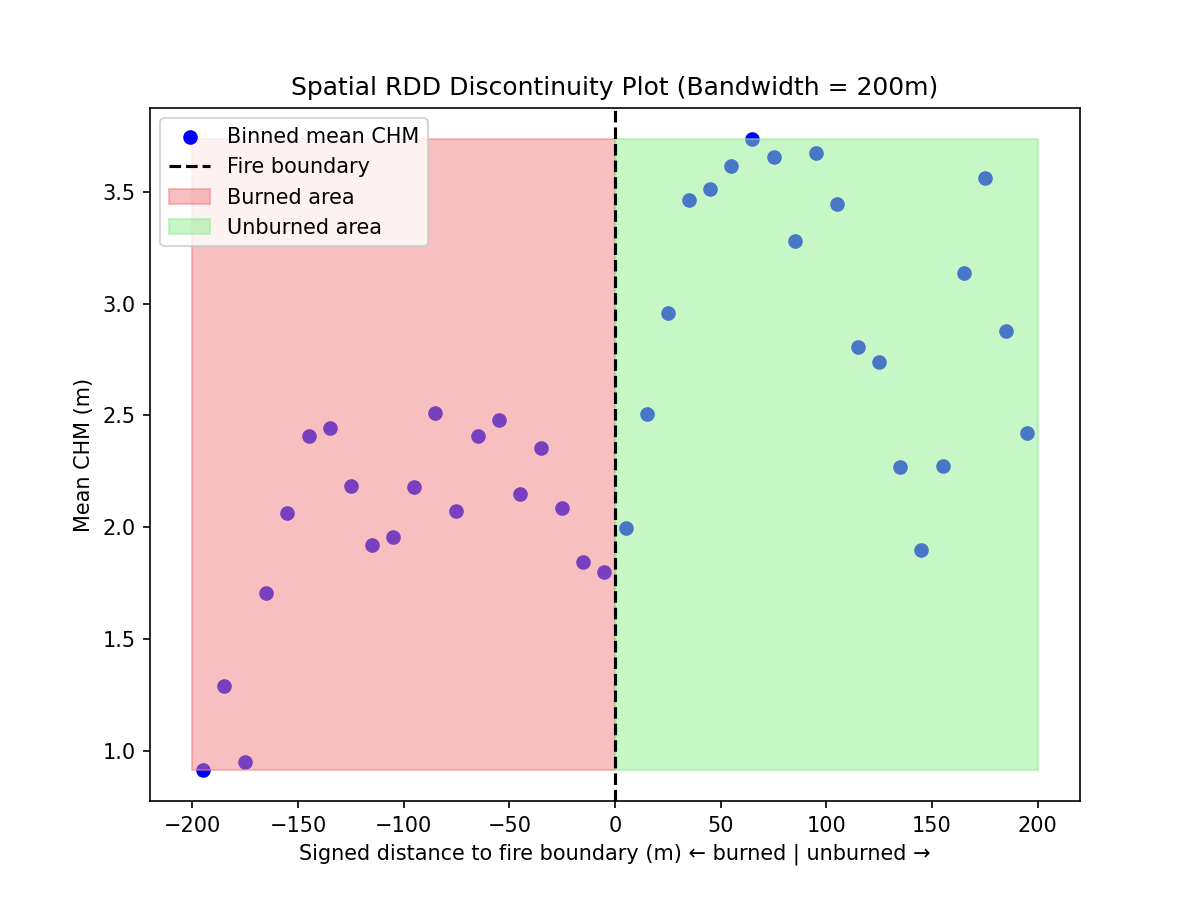

In [35]:
# Part 6 — Spatial RDD
# Implement the TODOs in validation/accuracy_assessment.py first, then uncomment.

from validation.accuracy_assessment import spatial_rdd

rdd_result = spatial_rdd(
    chm_path=chm_path,
    fire_perimeter_path=fire_perimeter_path,
    bandwidth_m=200,
    output_path=ROOT / "outputs",
)

print(f"RDD estimate : {rdd_result['rdd_estimate']:.3f} m  (negative = fire reduced height)")
print(f"Std error    : {rdd_result['se']:.3f} m")
print(f"95% CI       : [{rdd_result['ci_lower']:.3f}, {rdd_result['ci_upper']:.3f}]")
print(f"Pixels in window: {rdd_result['n_pixels']:,} at bandwidth={rdd_result['bandwidth_m']}m")

# Sensitivity across bandwidths (100, 200, 300m) — saved by spatial_rdd()
sens = pd.read_csv(ROOT / "outputs" / "tables" / "rdd_sensitivity.csv")
display(sens)

# Binned discontinuity plot — saved by spatial_rdd()
from IPython.display import Image
display(Image(ROOT / "outputs" / "figures" / f"spatial_rdd_bandwidth_{rdd_result['bandwidth_m']:.0f}m.png"))

---

### Reflection

> **TODO (draft):** The analysis flagged 1,547 exceedance polygons with a mean height of ~10m and a median of 5.8m within the 15m transmission line buffer — concentrated along the Sespe Creek riparian zone and the eastern orchard block. The Thomas Fire validation supports treating these as real vegetation: 66% of burned-zone pixels registered ≤0.5m canopy (bare ground), while unburned-zone median CHM was 1.23m. The mean inside the perimeter (2.0m) is elevated by transmission tower returns — the median and bare-ground rate are the defensible metrics. Overall the CHM signal is consistent with the physical ground truth the fire provides.

> **TODO:** Address limitations: the 2018 LiDAR snapshot understates current risk; the 15m buffer and 4.57m threshold are illustrative and need to be grounded in the actual line specs; the Thomas Fire overlap covers only ~20% of the tile so the validation sample is partial. LiDAR-based line detection is reliable for high-voltage transmission infrastructure (220kV lattice towers: 120–160 ft, large conductors) but degrades for subtransmission-class lines — the 66kV structures are wood poles at 40–70 ft with smaller-diameter conductors that do not produce structurally distinct returns at 5.92 pts/m², making the 66kV centerline difficult to trace directly from the point cloud even though vegetation returns within its corridor are visible.

> **TODO (draft — future work):** A complete operational analysis would require: (1) updated LiDAR or satellite-derived CHM — this 2018 survey is now 8 years old and pre-dates subsequent regrowth in the burn scar; GEDI or ICESat-2 could provide a recent height snapshot at lower resolution; (2) voltage-class-specific clearance thresholds pulled from actual utility easement records rather than the illustrative FAC-003-4 values used here; (3) multi-tile coverage — this 1 km² tile captures one segment; the full SCE corridor runs tens of kilometers; (4) comparison against utility vegetation inspection records to assess whether LiDAR-flagged polygons correspond to known encroachments; (5) Part 6 Spatial RDD — implement `spatial_rdd()` in `validation/accuracy_assessment.py` to upgrade the fire-perimeter comparison from descriptive to causal.

---

### Citations

| Data | Citation |
|---|---|
| USGS 3DEP LiDAR | U.S. Geological Survey, 3D Elevation Program. *SoCal Wildfires B3 2018 QL1 LiDAR.* Accessed via The National Map. |
| CA Transmission Lines | California Energy Commission. *Electric Transmission Lines.* ArcGIS REST API. `services3.arcgis.com/bWPjFyq029ChCGur` |
| Thomas Fire Perimeter | CAL FIRE. *California Fire Perimeters.* ArcGIS REST API, item `a2926cffbc854806befacbf85ebc9b95` |
| NERC Standard | North American Electric Reliability Corporation. *FAC-003-4: Transmission Vegetation Management.* 2016. |

> **TODO:** Add any additional citations for PDAL, laspy, geopandas, rioxarray, or contextily if required by your publication venue.